# Planet Temperature vs Star Temperature
---
equilibrium_temp_k does not depend on star_temp_k or Hotter stars = hotter planets

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
from matplotlib.lines import lineStyles
from openpyxl.styles.builtins import styles

Hypothesis Definition: Planet Temperature vs Star Temperature

In this section, we define the statistical hypothesis that will guide the analysis of the relationship between planetary equilibrium temperature (equilibrium_temp_k) and the host star’s temperature (star_temp_k).

The null hypothesis (H0) assumes that there is no dependency between the two variables, meaning that changes in the star’s temperature do not influence the planet’s equilibrium temperature.

The alternative hypothesis (H1) suggests a direct relationship, where planets orbiting hotter stars tend to have higher equilibrium temperatures.

In [29]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Planet Temperature vs Star Temperature': ['equilibrium_temp_k does not depend on star_temp_k', 'Hotter stars = hotter planets']
}
planet_temp_vs_star_temp = pd.DataFrame(data)
planet_temp_vs_star_temp

,Hypothesis,Planet Temperature vs Star Temperature
0,H0,equilibrium_temp_k does not depend on star_temp_k
1,H1,Hotter stars = hotter planets


In [30]:
# Load the dataset
data = pd.read_csv('../data/nasa_exoplanet_intelligence.csv')
data

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


Data Preparation and Statistical Test

In this step, the dataset is filtered to include only the relevant numerical variables: equilibrium_temp_k and star_temp_k.

Any rows containing missing values (NaN) are removed

In [31]:
# equilibrium_temp_k - nan values check
data['equilibrium_temp_k'].isna().sum()

np.int64(1563)

In [41]:
# In this step, we isolate and examine the observations where equilibrium_temp_k is missing (NaN).
# This allows us to better understand the structure and potential patterns behind the missing data.
data[data['equilibrium_temp_k'].isna()]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
36,HD 205739 b,HD 205739,1,1,Radial Velocity,2008.0,Las Campanas Observatory,279.80000,13.60,435.410000,...,324.535127,-31.737837,0,Gas Giant,False,False,False,Nearby(<100pc),F-type,Long(100-365d)
38,HD 224693 b,HD 224693,1,1,Radial Velocity,2006.0,W. M. Keck Observatory,26.69040,14.00,222.481000,...,359.974984,-22.428000,0,Gas Giant,False,False,False,Nearby(<100pc),G-type(Sun-like),Medium(10-100d)
39,HD 156279 b,HD 156279,1,2,Radial Velocity,2011.0,Haute-Provence Observatory,133.40355,12.50,2997.757535,...,258.096669,63.352783,0,Gas Giant,False,True,False,Nearby(<100pc),G-type(Sun-like),Long(100-365d)
40,HD 12661 b,HD 12661,1,2,Radial Velocity,2000.0,Multiple Observatories,262.70862,13.30,772.326900,...,31.142353,25.413563,0,Gas Giant,False,True,False,Nearby(<100pc),G-type(Sun-like),Long(100-365d)
41,HD 16417 b,HD 16417,2,1,Radial Velocity,2008.0,Anglo-Australian Telescope,17.24000,5.00,22.100000,...,39.244103,-34.579090,0,Neptune-like,False,False,False,Nearby(<100pc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6140,HD 181433 c,HD 181433,1,3,Radial Velocity,2008.0,La Silla Observatory,1018.50000,NaN,2207.000458,...,291.287373,-66.467784,0,Unknown,False,True,False,Nearby(<100pc),K-type,Very-Long(365d+)
6141,DMPP-7 b,DMPP-7,1,1,Radial Velocity,2026.0,Multiple Observatories,4.98400,9.13,61.390000,...,203.528465,0.498813,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Short(1-10d)
6142,KMT-2024-BLG-0349L b,KMT-2024-BLG-0349L,1,1,Microlensing,2026.0,KMTNet,NaN,12.40,3769.444907,...,261.371542,-30.247019,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6143,HD 164604 b,HD 164604,1,2,Radial Velocity,2009.0,Las Campanas Observatory,653.90000,12.30,4195.334972,...,270.778718,-28.560834,0,Gas Giant,False,True,False,Nearby(<100pc),K-type,Very-Long(365d+)


In [38]:
# star_temp_k - nan values check
data['star_temp_k'].isna().sum()

np.int64(290)

In [43]:
data[data['star_temp_k'].isna()]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
85,MOA-2009-BLG-266L b,MOA-2009-BLG-266L,1,1,Microlensing,2011.0,MOA,2800.0000,3.210,10.400000,...,267.008125,-35.005411,0,Mini-Neptune,False,False,False,Distant(2k+pc),Unknown,Very-Long(365d+)
90,PSR B1257+12 b,PSR B1257+12,1,3,Pulsar Timing,1994.0,Arecibo Observatory,25.2620,0.338,0.020000,...,195.014903,12.682353,0,Sub-Earth,False,True,False,Far(500-2kpc),Unknown,Medium(10-100d)
91,PSR B1257+12 d,PSR B1257+12,1,3,Pulsar Timing,1992.0,Arecibo Observatory,98.2114,1.800,3.900000,...,195.014903,12.682353,0,Mini-Neptune,False,True,False,Far(500-2kpc),Unknown,Medium(10-100d)
92,MOA-2007-BLG-192L b,MOA-2007-BLG-192L,1,1,Microlensing,2008.0,MOA,NaN,1.630,3.300000,...,272.015825,-27.150075,0,Super-Earth,False,False,False,Far(500-2kpc),Unknown,Unknown
97,SWEEPS-11 b,SWEEPS-11,1,1,Transit,2006.0,Hubble Space Telescope,1.7960,12.666,3082.820000,...,269.758333,-29.198194,0,Gas Giant,False,False,False,Distant(2k+pc),Unknown,Short(1-10d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6097,KMT-2019-BLG-0953L b,KMT-2019-BLG-0953L,1,1,Microlensing,2022.0,KMTNet,NaN,4.060,15.500000,...,269.338583,-28.674639,0,Neptune-like,False,False,True,Distant(2k+pc),Unknown,Unknown
6116,KMT-2024-BLG-1005L b,KMT-2024-BLG-1005L,1,1,Microlensing,2025.0,KMTNet,NaN,12.100,6674.396547,...,269.805583,-28.755781,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6135,KMT-2024-BLG-0176L b,KMT-2024-BLG-0176L,1,1,Microlensing,2026.0,KMTNet,NaN,14.000,241.549589,...,266.532458,-34.210581,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6142,KMT-2024-BLG-0349L b,KMT-2024-BLG-0349L,1,1,Microlensing,2026.0,KMTNet,NaN,12.400,3769.444907,...,261.371542,-30.247019,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown


In [39]:
+cleaned_data = data[['equilibrium_temp_k', 'star_temp_k']].dropna()

In [34]:
# Analysis of Selected Features
cleaned_data['equilibrium_temp_k'].describe()

count    4577.000000
mean      912.652290
std       461.834783
min        55.900000
25%       567.000000
50%       818.000000
75%      1163.000000
max      4050.000000
Name: equilibrium_temp_k, dtype: float64

In [35]:
cleaned_data['star_temp_k'].describe()

count     4577.000000
mean      5372.504573
std        881.339827
min        415.000000
25%       4996.000000
50%       5591.000000
75%       5925.000000
max      13646.000000
Name: star_temp_k, dtype: float64

Significance Level and Hypothesis Decision Rule

In this analysis, we use a significance level of a = 0.01, which corresponds to a 99% confidence level.

The decision rule is defined as follows:

If the p-value is below 0.01, we reject the null hypothesis (H0).
If the p-value is over or equal 0.01, we fail to reject the null hypothesis (H0).

This threshold ensures a strict criterion for statistical significance, reducing the probability of committing a Type I error (false positive).

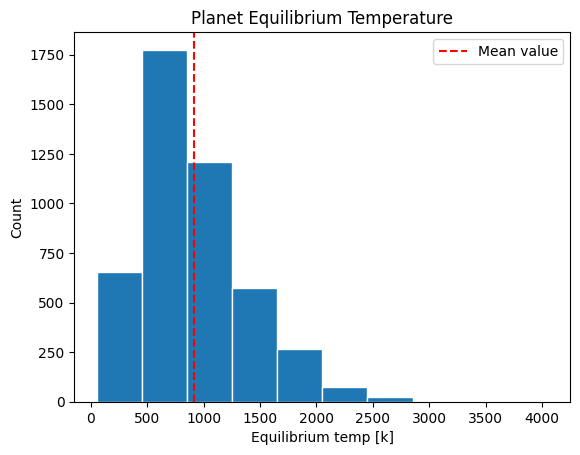

In [36]:
plt.hist(cleaned_data['equilibrium_temp_k'], edgecolor='white')

mean_value = cleaned_data['equilibrium_temp_k'].mean()
plt.axvline(mean_value, color='r', linestyle='--', label='Mean value')

plt.title('Planet Equilibrium Temperature')
plt.xlabel('Equilibrium temp [k]')
plt.ylabel('Count')
plt.legend()
plt.show()

For a detailed explanation of the `Kelvin` temperature scale - https://en.wikipedia.org/wiki/Kelvin

Despite the large proportion of missing values, we proceed with the test and examine the results.

In this case, the p-value is negligibly small (approaching zero), which provides strong evidence against the null hypothesis.

Therefore, we reject the null hypothesis (H0).

In [37]:
st.ttest_rel(cleaned_data['equilibrium_temp_k'], cleaned_data['star_temp_k'])

TtestResult(statistic=np.float64(-376.4407334345164), pvalue=np.float64(0.0), df=np.int64(4576))